In [ ]:
# This section is copied from the Employees dataset we did in class
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns
#########################################################################
# Set this to displays the enitre data:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
#########################################################################

import warnings
warnings.filterwarnings('ignore')

def take_a_look (data_to_look):
    """
    Display basic information about an input dataframe
    Parameters:
    data_to_look: data to look at -> Dtype: data frame
    """
    print(data_to_look.info())
    print()
    print(data_to_look.describe())

def correlation_columns (data, col_1, col_2):
    corr_value = data[col_1].corr(data[col_2])
    return round(corr_value, 4) *100

def get_subset_threshold(data, column, threshold, condition):
    """
    This function generates subsets based on numerical column value
    Parameters:
    data: data to filter -> Dtype: data frame
    column: filter based on this column -> Dtype: string
    threshold: value above/below you want to filter the data -> Dtype: float
    condition: takes two possible values (greater than or equal to/ lesser than) -> Dtype: string
    """
    if condition == '>=':
        mask = data[column] >= threshold
        data_mask = data[mask]
    else:
        mask = data[column] < threshold
        data_mask = data[mask]

    return data_mask

def get_subset_exact(data, column, column_value):

    """
    This function generates subsets based on categorical column value
    Parameters:
    data: data to filter -> Dtype: data frame
    column: filter based on this column -> Dtype: string
    column value: values that are equal to this are filterd -> Dtype: string
    """
    mask = data[column] == column_value
    data_mask = data[mask]

    return data_mask

def salary_report(data, feature):

    """
    This function generates a report for average salaries per unique values in a given feature
    Parameters:
    data: data to generate the report -> dtype: DataFrame
    feature: column name on which the report will be generated -> dtype: String
    """
    salaries = []
    unique_features = data[feature].unique()
    for i in unique_features:
        data_feature = get_subset_exact(data, feature,i)
        salary = np.around(np.mean(data_feature['Annual Salary']), 2)
        salaries.append(salary)
    salary_report = pd.DataFrame({feature: unique_features, 'Annual Salary':salaries})

    return salary_report

def categorical_numeric_means(data, categorical, column):
    """
    Finds mean of input numeric column for each unique value in the input categorical column
    data: data to generate means for -> dtype: DataFrame
    categorical: categorical column title -> dtype: String
    column: numeric column title -> dtype: String
    """
    cat_values = data[categorical].unique()
    mean_list = []
    for category in cat_values:
        data_of_cat = get_subset_exact(data, categorical, category)
        mean = np.around(data_of_cat[column].mean(), 2)
        mean_list.append(mean)
    mean_dict = {categorical: cat_values,
                 'Mean': mean_list}
    cat_mean_data = pd.DataFrame(mean_dict)
    return cat_mean_data

def income_tally_by_categorical(data, categorical):
    """
    Tallies how many people earn over 50k and under 50k
    based on the input categorical variable
    Parameters: data data used to generate tallies-> dtype: DataFrame
    categorical category title to sort tallies by -> dtype: String
    """
    cat_values = data[categorical].unique()
    tally_dict = {categorical: [],
                  'over 50k': [],
                  'under 50k': [],
                  'percent over 50k': []}
    for category in cat_values:
        data_of_cat = get_subset_exact(data, categorical, category)
        tally = data_of_cat['income'].value_counts()
        try: over_50k = tally['>50K']
        except: over_50k = 0

        try: under_50k = tally['<=50K']
        except: under_50k = 0
        percent = (over_50k/(under_50k + over_50k))*100
        tally_dict[categorical].append(category)
        tally_dict['under 50k'].append(under_50k)
        tally_dict['over 50k'].append(over_50k)
        tally_dict['percent over 50k'].append(percent)
    cat_income_tally = pd.DataFrame(tally_dict)
    return cat_income_tally

def my_StdSclr(data_to_scale):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_to_scale)
    data_SS = pd.DataFrame(scaled_data,columns=data_to_scale.columns)
    return data_SS

def add_labels(x,y):
    for i,j in zip(x, y):
        plt.text(i,j,  j, ha='center', va = 'bottom')

In [ ]:
#reading dataset, excluding 99999 in capital gains because it is representative of a null value
data = pd.read_csv('/content/Adult_dataset.csv', na_values={'capital-gain': 99999})
# adds an integer column for if income is greater than 50k
data['over_50k'] = (data['income'] == '>50K').astype(int)

In [ ]:
#correlations table
numerical_columns = data[['age', 'fnlwgt','educational-num','capital-gain','capital-loss','hours-per-week','over_50k']]
numerical_columns.corr()


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,over_50k
age,1.000000,-0.075792,0.037623,0.115972,0.059351,0.101992,0.237040
fnlwgt,-0.075792,1.000000,-0.041993,-0.003985,-0.004349,-0.018679,-0.007264
educational-num,0.037623,-0.041993,1.000000,0.144173,0.081711,0.146206,0.332800
capital-gain,0.115972,-0.003985,0.144173,1.000000,-0.051076,0.083500,0.307709
capital-loss,0.059351,-0.004349,0.081711,-0.051076,1.000000,0.054195,0.148687
hours-per-week,0.101992,-0.018679,0.146206,0.083500,0.054195,1.000000,0.227199
over_50k,0.237040,-0.007264,0.332800,0.307709,0.148687,0.227199,1.000000


# Q1: How does income vary across different education levels?

In [ ]:
#tally incomes by education level and caluclate the percentage who earn over 50k
education_income_tally = income_tally_by_categorical(data, 'education')
#show table of results
education_income_tally

,education,over 50k,under 50k,percent over 50k
0,11th,89,1530,5.497221
1,HS-grad,2416,12367,16.343097
2,Assoc-acdm,398,1109,26.410086
3,Some-college,1990,7909,20.103041
4,10th,82,1141,6.704824
5,Prof-school,592,193,75.414013
6,7th-8th,55,768,6.682868
7,Bachelors,3178,4392,41.981506
8,Masters,1393,1121,55.409706
9,5th-6th,22,427,4.899777


# Q2: What is the frequency distribution of income levels for each workclass category?

In [ ]:
# Gets a list of unique work classes
workclass_unique = data['workclass'].unique()
workclass_income = income_tally_by_categorical(data, 'workclass')

high_pay_workclass = []
low_pay_workclass = []
# Counts up the amount of people in each workclass that make more than 50k and less than 50k
workclass_income = income_tally_by_categorical(data, 'workclass')

In [ ]:
# Gets the values of low pay and high pay
for i in range(0, workclass_unique.size):
    high_pay_workclass.append(workclass_income.iloc[i][1])
    low_pay_workclass.append(workclass_income.iloc[i][2])

In [ ]:
# Setting up a grouped bar graph
bar_width = 0.4

x_axis = np.arange(len(workclass_unique))

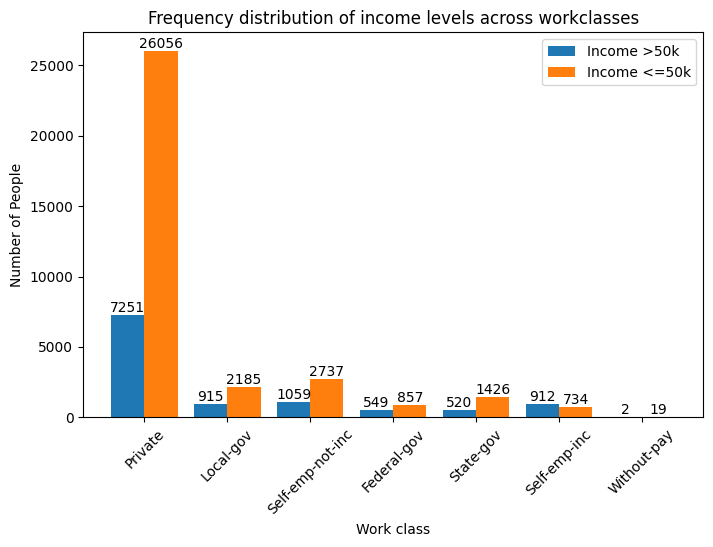

In [ ]:
# Graphs the data in a grouped bar graph
plt.figure(figsize=(8,5))

plt.bar(x_axis-.2, high_pay_workclass,width = bar_width, label="Income >50k")
plt.bar(x_axis+.2, low_pay_workclass,width = bar_width,label="Income <=50k")
add_labels(x_axis-0.2, high_pay_workclass)
add_labels(x_axis+0.2, low_pay_workclass)

plt.legend()
plt.xlabel("Work class")
plt.ylabel("Number of People")
plt.title("Frequency distribution of income levels across workclasses")
plt.xticks(x_axis, workclass_unique,rotation=45)
plt.show()

# Q3: How does the average age differ between individuals earning >50k and those earning <=50k?

In [ ]:
#Create a dataframe containing the average age of people earning <=50k and >50k
age_income_avg = categorical_numeric_means(data, 'income', 'age')

#summarize results of dataframe
print('The average age of people earning', age_income_avg['income'][0], 'is', age_income_avg['Mean'][0], 'years old')
print('The average age of people earning', age_income_avg['income'][1], 'is', age_income_avg['Mean'][1], 'years old')
print('On average people earning', age_income_avg['income'][1], 'are', np.round((age_income_avg['Mean'][1]-age_income_avg['Mean'][0]),2),'years older than people earning', age_income_avg['income'][0])

The average age of people earning <=50K is 36.75 years old
The average age of people earning >50K is 44.01 years old
On average people earning >50K are 7.26 years older than people earning <=50K


# Q4: What is the relationship between martial status and income levels?

In [ ]:
# Makes a mask of all of the types of marriage in the csv
mask_married = ((data['marital-status'] == 'Married-civ-spouse') |
                    (data['marital-status'] == 'Married-AF-spouse') |
                    (data['marital-status'] == 'Married-spouse-absent'))
data_married = data[mask_married]

In [ ]:
# Finds the count of Married people with an income above 50k
married_high_income = np.where(data_married['over_50k'] == True)
married_high_income_count = len(married_high_income[0]) # -> 9632

# Finds the count of Married people with an income below 50k
married_low_income = np.where(data_married['over_50k'] == False)
married_low_income_count = len(married_low_income[0]) # 12007

# Finds the percentage of married people with high income
married_percentage_high = round(married_high_income_count / (married_high_income_count + married_low_income_count) * 100,2) # -> 44.51

In [ ]:
# Makes a mask of people not currently married (flips the married mask)
mask_not_married = ~mask_married
data_not_married = data[mask_not_married]

In [ ]:
# Finds the count of unmarried people with an income above 50k
not_married_high_income = np.where(data_not_married['over_50k'] == True)
not_married_high_income_count = len(not_married_high_income[0]) # 1576

# Finds the count of unmarried people with an income below 50k
not_married_low_income = np.where(data_not_married['over_50k'] == False)
not_married_low_income_count = len(not_married_low_income[0]) # 22007

# Finds the percentage of unmarried people with high income
not_married_percentage_high = round(not_married_high_income_count / (not_married_high_income_count + not_married_low_income_count) * 100 ,2) # -> 6.68

In [ ]:
# Prints out the results
print(married_percentage_high,"% of married adults have an income above 50k") # -> 44.51%
print(not_married_percentage_high,"% of unmarried adults have an income above 50k") # -> 6.68%

44.51 % of married adults have an income above 50k
6.68 % of unmarried adults have an income above 50k


# Q5: Is there a significant difference in capital gains between high-income and low-income groups?


In [ ]:
#find mean capital gains for each income category
cap_gain_income_avg = categorical_numeric_means(data, 'income', 'capital-gain')
#print out the results
print('The average capital-gains of people earning', cap_gain_income_avg['income'][0], 'is', '$'+str(cap_gain_income_avg['Mean'][0])+'.',
      '\nThe average capital-gains of people earning', cap_gain_income_avg['income'][1], 'is', '$'+str(cap_gain_income_avg['Mean'][1])+'.',
      '\nThis is a significant gap between the two groups given the majority of people earn no capital gains.')


The average capital-gains of people earning <=50K is $149.02. 
The average capital-gains of people earning >50K is $1989.27. 
This is a significant gap between the two groups given the majority of people earn no capital gains.


# Q1: How does age impact income? What age earns the most on average?

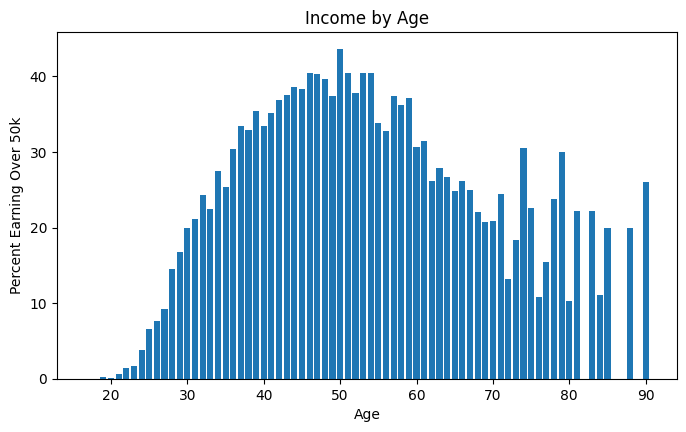

In [ ]:
#Creagte a bar chart of income by age. Include all ages in bar
age_income_tally = income_tally_by_categorical(data, 'age')
age_income_tally.sort_values(by='age')
plt.figure(figsize=(8,4.5))
plt.bar(age_income_tally['age'], age_income_tally['percent over 50k'])
plt.xlabel('Age')
plt.ylabel('Percent Earning Over 50k')
plt.title('Income by Age')
plt.show()
age_income_tally = age_income_tally.sort_values(by='percent over 50k', ascending= False, ignore_index=True)
#print the age with highest earnings
print(f"People aged {age_income_tally['age'][0]} earn the most with {np.round(age_income_tally['percent over 50k'][0],2)}% earning over 50k")

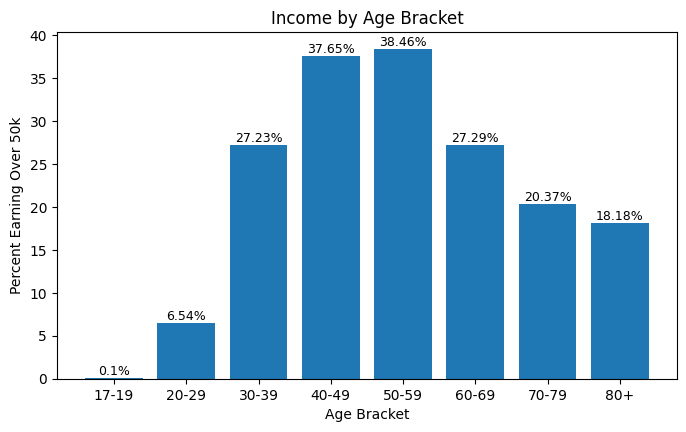

In [ ]:
#Divide into age brackets to account for some ages having low entries
data['Age Bracket'] = data['age']//10*10

#rename age brackets in loop
for value in data['Age Bracket'].unique():
    new_value = str(value)+'-'+str(value+9)
    data['Age Bracket'].replace(value, new_value, inplace=True)

#rename age brackets to reflect minimum age of 17
data['Age Bracket'].replace('10-19', '17-19',inplace=True)

#max age is 90 with small sample size, group into 80+ category
data['Age Bracket'].replace('90-99', '80+',inplace=True)
data['Age Bracket'].replace('80-89', '80+',inplace=True)

#tally and sort income levels by age bracket
age_bracket_income_tally = income_tally_by_categorical(data, 'Age Bracket')
age_bracket_income_tally.sort_values(by='Age Bracket', ignore_index=True, inplace=True)

#create bar chart of percentage of people earning over 50k by age bracket
plt.figure(figsize=(8,4.5))
plt.bar(age_bracket_income_tally['Age Bracket'], age_bracket_income_tally['percent over 50k'])

#label chart
for i,j in zip(np.arange(8), age_bracket_income_tally['percent over 50k']):
    plt.text(i,j, str(np.round(j,2))+'%', ha='center', va = 'bottom', fontsize=9)
plt.xlabel('Age Bracket')
plt.ylabel('Percent Earning Over 50k')
plt.title('Income by Age Bracket')
plt.show()

# Q2: How do hours-per-week relate to education level? Does a lower level of education mean higher hours per week?

In [ ]:
# Gets the unique hours worked
hours_unique = data['hours-per-week'].unique()
hours_unique.sort()
hours_unique

# Gets the unique education levels
education_unique = data['education'].unique()
education_unique

# Gets the number for each education level
edu_num_unique = data['educational-num'].unique()
edu_num_unique

array([ 7,  9, 12, 10,  6, 15,  4, 13, 14,  3, 11,  5, 16,  8,  2,  1])

In [ ]:
# Gets the average hours per week worked for each education level
average_hours = []

for i in education_unique:
    data_edu = get_subset_exact(data,'education', i)
    hours = np.around(np.mean(data_edu['hours-per-week']), 2)
    average_hours.append(hours)

In [ ]:
# Make a dataFrame and organize the data by education level
hours_edu_data = {'Education': education_unique, 'Education Number':edu_num_unique,'Average Hours per week':average_hours}
table_hours_education = pd.DataFrame(hours_edu_data)
table_hours_education.sort_values(by = 'Education Number', ignore_index= True, ascending= True, inplace = True)
table_hours_education

,Education,Education Number,Average Hours per week
0,Preschool,1,36.79
1,1st-4th,2,39.18
2,5th-6th,3,38.84
3,7th-8th,4,39.81
4,9th,5,39.00
5,10th,6,37.51
6,11th,7,34.35
7,12th,8,35.58
8,HS-grad,9,41.10
9,Some-college,10,39.48


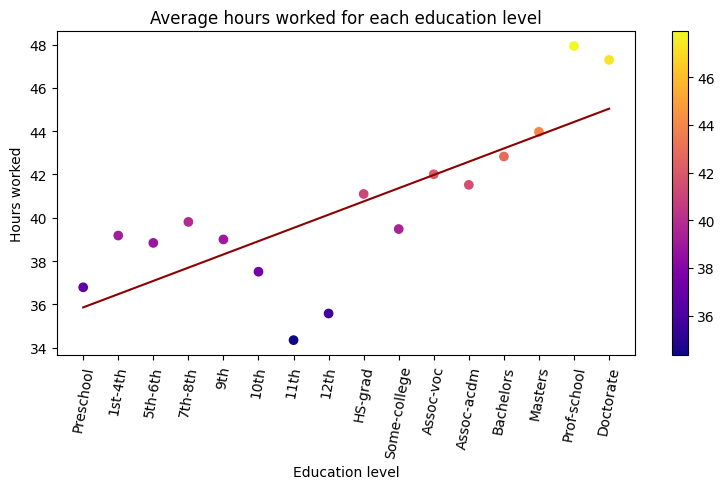

On average, a higher education level relates to working more hours per week


In [ ]:
# Graphs the average hours for each education level into a scatter plot
education_level = table_hours_education['Education']
education_numerical = table_hours_education['Education Number']
avg_hours_per_edu = table_hours_education['Average Hours per week']
plt.figure(figsize=(8,5))
plt.title("Average hours worked for each education level")
plt.xlabel("Education level")
plt.xticks(rotation = 80)
plt.ylabel("Hours worked")
plt.scatter(education_level, avg_hours_per_edu, c=avg_hours_per_edu, cmap='plasma')
m, b = np.polyfit(education_numerical, avg_hours_per_edu, 1)
plt.plot(education_level, m*education_numerical + b, color='darkred')
plt.colorbar()
plt.tight_layout()
plt.savefig("Hours_education_scatter.png")
plt.show()
print("On average, a higher education level relates to working more hours per week")

# Q3: What are the most common features of the dataset and what percentage of the dataset do people with the features take up?

In [ ]:
# Sorting the data by fnlwgt. fnlwgt is an estimate of the number of individuals in the population with the same demographics as this individual
sorted_data = data.sort_values(by = 'fnlwgt', ignore_index= True, ascending= False)
sorted_data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,over_50k,Age Bracket
0,27,Private,1490400,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0,40,United-States,<=50K,0,20-29
1,25,Private,1484705,Some-college,10,Divorced,Exec-managerial,Unmarried,White,Female,0.0,0,25,United-States,<=50K,0,20-29
2,39,Private,1455435,Assoc-acdm,12,Separated,Craft-repair,Not-in-family,White,Male,0.0,0,40,United-States,<=50K,0,30-39
3,45,Private,1366120,Assoc-voc,11,Divorced,Other-service,Not-in-family,White,Female,0.0,0,8,United-States,<=50K,0,40-49
4,29,Private,1268339,HS-grad,9,Married-spouse-absent,Tech-support,Own-child,Black,Male,0.0,0,40,United-States,<=50K,0,20-29


From here, we can see that the most common aspects are:
1.   private workclass
2.   no spouse (divorced/seperated/spouse absent)
3. white
4. From the US
5. Less than 50k income


what percentage do people with the most common features make up in the dataset?

In [ ]:
# Masks for each category

# Workclass mask
mask_workclass = data['workclass'] == 'Private'

# no present spouse mask
mask_no_spouse = ((data['marital-status'] == 'Never-married') |
                    (data['marital-status'] == 'Widowed') |
                    (data['marital-status'] == 'Married-spouse-absent') |
                    (data['marital-status'] == 'Seperated') |
                 (data['marital-status'] == 'Divorced'))

# race mask
mask_race = data['race'] == 'White'

# native country mask
mask_country = data['native-country'] == 'United-States'

# mask for income
mask_income = data_married['over_50k'] == False

# combines all of the masks into one
combined_mask = mask_workclass & mask_no_spouse & mask_race & mask_country & mask_country

# the dataset with the masks
common_data = data[combined_mask]
common_data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,over_50k,Age Bracket
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0.0,0,30,United-States,<=50K,0,30-39
6,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0.0,0,40,United-States,<=50K,0,20-29
10,26,Private,82091,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0.0,0,39,United-States,<=50K,0,20-29
15,37,Private,60548,HS-grad,9,Widowed,Machine-op-inspct,Unmarried,White,Female,0.0,0,20,United-States,<=50K,0,30-39
21,22,Private,236427,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0.0,0,20,United-States,<=50K,0,20-29


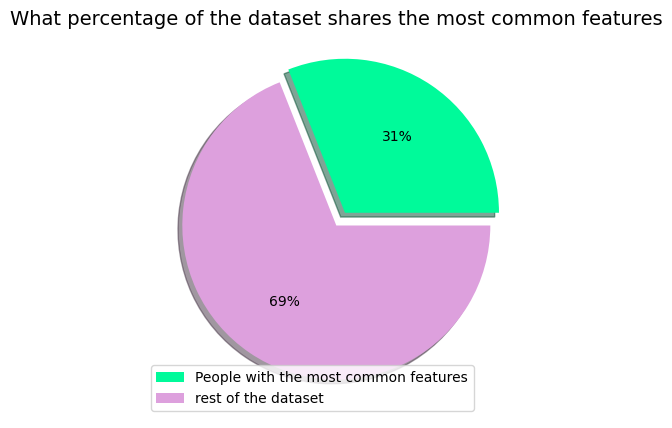

In [ ]:
# Plots the percentage of people with the most common features in the dataset
pie_data = [len(common_data), (len(data) - len(common_data))]
explode = [0.1, 0.0]
labels = ['People with the most common features', 'rest of the dataset']
colors=['mediumspringgreen','plum']
plt.figure(figsize=(8,5))
plt.title('What percentage of the dataset shares the most common features', fontsize=14)
plt.pie(pie_data, explode=explode, colors=colors,autopct='%.0f%%', shadow=True)
plt.legend(labels)
plt.savefig("common_feature_pie.png")
plt.show()

# Q4: What is the average capital (gain & loss) for each occupation?

In [ ]:
# Unique jobs
unique_job = data['occupation'].unique()
unique_job

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [ ]:
# Gets the capital gain, loss, and average for each occupation
capital_gain = []
capital_loss = []
average_capital = []

# labels for the chart
occupation_labels = []

for job in unique_job:
    data_occupation = get_subset_exact(data,'occupation', job)
    capital_gain.append(data_occupation['capital-gain'].values)
    capital_loss.append(data_occupation['capital-loss'].values)
    # the - sign is to take into account for the 'capital-loss' column being a positive number
    average_capital.append(np.around(np.nanmean((data_occupation['capital-gain'], -data_occupation['capital-loss'])),2))
    occupation_labels.append(job)

average_capital

[np.float64(108.58),
 np.float64(229.4),
 np.float64(216.06),
 np.float64(54.75),
 np.float64(490.19),
 np.float64(190.09),
 np.float64(134.39),
 np.float64(522.63),
 np.float64(247.17),
 np.float64(279.63),
 np.float64(75.54),
 np.float64(162.16),
 np.float64(69.74),
 np.float64(193.25)]

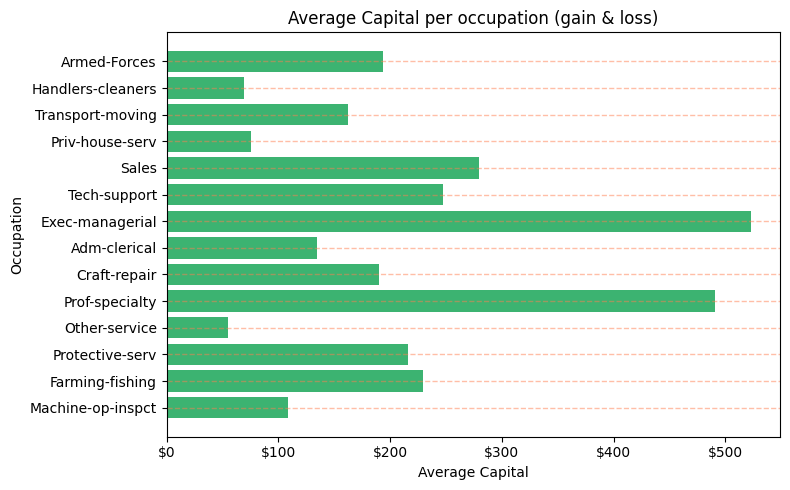

In [ ]:
# Plots the average capital in a horizontal bar plot because the spread boxplot is hard to read/get data from lol
plt.figure(figsize=(8,5))
plt.barh(occupation_labels,average_capital,color='mediumseagreen')
# adds a nice horizontal line :)
plt.grid(color='coral', linestyle='--', linewidth=1.0, axis='y', alpha=0.5)
plt.xlabel('Average Capital')
# this line formats the x axis to have a dollar sign in front of the amount as well as a comma to numbers above 1,000
plt.gca().xaxis.set_major_formatter('${:,.0f}'.format)
plt.ylabel('Occupation')
plt.title('Average Capital per occupation (gain & loss)')
plt.tight_layout()
plt.savefig("average_capital.png")
plt.show()

# Q5: Do people who are not native to the United States have different occupations?

In [ ]:
#seperate data by native country
native_mask = data['native-country'] == 'United-States'
not_native_mask = data['native-country'] != 'United-States'
native = data[native_mask]
not_native = data[not_native_mask]

#count occupations
occupations_native = native['occupation'].value_counts()
occupations_not_native = not_native['occupation'].value_counts()
occupations_not_native['Armed-Forces'] = 0

#convert to percentage of total in group
occupations_native_percent = (occupations_native / native.shape[0])*100
occupations_not_native_percent = (occupations_not_native / not_native.shape[0])*100

#sort indexes for graphing
occupations_native_percent.sort_index(inplace=True)
occupations_not_native_percent.sort_index(inplace=True)

#put into table to read specific values
occupations_comparison = pd.DataFrame({'Native': occupations_native_percent, 'Not Native': occupations_not_native_percent})
occupations_comparison

,Native,Not Native
occupation,,
Adm-clerical,12.447932,10.178117
Armed-Forces,0.033905,0.000000
Craft-repair,13.327037,13.155216
Exec-managerial,13.576480,9.618321
Farming-fishing,3.160418,4.452926
Handlers-cleaners,4.378572,6.055980
Machine-op-inspct,6.202170,10.407125
Other-service,10.130292,15.903308
Priv-house-serv,0.372954,1.984733


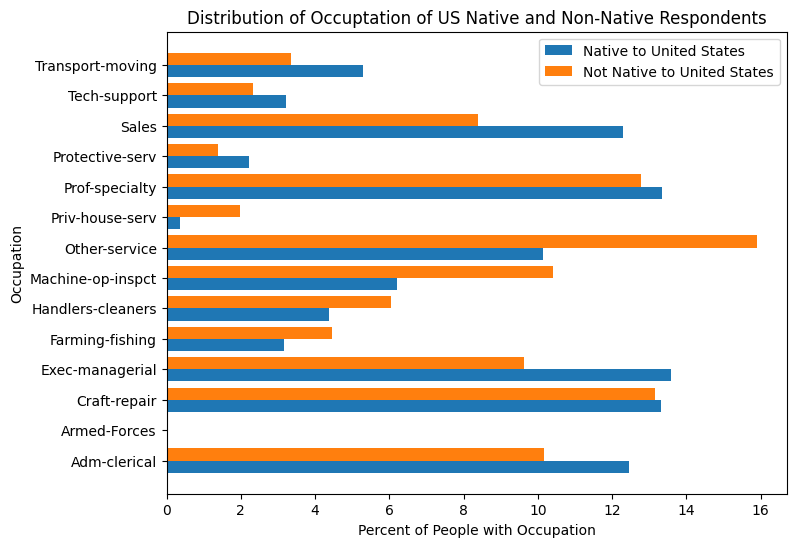

In [ ]:
#set up and graph results in stacked bar
occupation_index = occupations_native_percent.index.to_list()
y_axis= np.arange(len(occupation_index))
#Native
plt.figure(figsize=(8,6))
plt.barh(y_axis-.2,
        occupations_native_percent.to_list(),
        height=bar_width,
        label='Native to United States')
#Non-Native
plt.barh(y_axis+.2,
        occupations_not_native_percent.to_list(),
        height=bar_width,
        label='Not Native to United States')
plt.xlabel('Percent of People with Occupation')
plt.ylabel('Occupation')
plt.title('Distribution of Occuptation of US Native and Non-Native Respondents')
plt.yticks(y_axis, occupation_index)
plt.legend()
plt.show()

# Classification and Model Evaluation

In [ ]:
# Data gets reimported due to the extra column we added messing with the models
data = pd.read_csv('/content/Adult_dataset.csv')

# Sets up x and y variables from the data
data['income'] = data['income'].map({'<=50K': 0, '>50K': 1})
X_independent = data.drop(columns = 'income')
Y_dependent = pd.DataFrame(data['income'])
X_independent_one_hot = X_independent.apply(LabelEncoder().fit_transform)
x_scaled = my_StdSclr(X_independent_one_hot)

In [ ]:
# Sets up arrays for graphing purposes
tests = ["Accuracy", "Precision", "Recall", "F1 Score"]
x_axis = np.arange(len(tests))
random_forest_scores = []
svm_scores = []
decision_tree_scores = []

In [ ]:
# Splits the data -> this is used by all 3 tests
X_train, X_test, y_train, y_test = train_test_split(x_scaled, Y_dependent, test_size = 0.2) # 80% train 20% test

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Support Vector Machine
# Initialize and train the SVM Classifier
svm_model = SVC(probability=True)

# Trains the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_scaled)
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:,1]

# Evaluate the model & adds to the array for the graph
print("Support Vector Machine")
print("Model evaluation:")
print(confusion_matrix(y_test, y_pred))
print ("Accuracy : ", accuracy_score(y_test, y_pred))
svm_scores.append(accuracy_score(y_test, y_pred))
print ("Precision : ", precision_score(y_test, y_pred))
svm_scores.append(precision_score(y_test, y_pred))
print ("Recall : ", recall_score(y_test, y_pred))
svm_scores.append(recall_score(y_test, y_pred))
print ("F1 Score : ", f1_score(y_test, y_pred))
svm_scores.append(f1_score(y_test, y_pred))

Support Vector Machine
Model evaluation:
[[6335  415]
 [1038 1257]]
Accuracy :  0.8393587617468214
Precision :  0.7517942583732058
Recall :  0.5477124183006536
F1 Score :  0.6337282581295689


In [ ]:
# Decision Tree
# Initialize and train the Decision tree Classifier
dt_model = DecisionTreeClassifier()

# Trains the model
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = dt_model.predict(X_test_scaled)
y_pred_probability = dt_model.predict_proba(X_test_scaled)[:,1]

# Evaluate the model & adds to the array for the graph
print("Decision Tree")
print("Model evaluation:")
print(confusion_matrix(y_test, y_pred))
print ("Accuracy : ", accuracy_score(y_test, y_pred))
decision_tree_scores.append(accuracy_score(y_test, y_pred))
print ("Precision : ", precision_score(y_test, y_pred))
decision_tree_scores.append(precision_score(y_test, y_pred))
print ("Recall : ", recall_score(y_test, y_pred))
decision_tree_scores.append(recall_score(y_test, y_pred))
print ("F1 Score : ", f1_score(y_test, y_pred))
decision_tree_scores.append(f1_score(y_test, y_pred))

Decision Tree
Model evaluation:
[[5873  877]
 [ 846 1449]]
Accuracy :  0.8095080154781648
Precision :  0.6229578675838349
Recall :  0.6313725490196078
F1 Score :  0.62713698333694


In [ ]:
# Random Forest
# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier()

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:,1]

# Evaluate the model & adds to the array for the graph
print("Random forest")
print("Model evaluation:")
print(confusion_matrix(y_test, y_pred))
print ("Accuracy : ", accuracy_score(y_test, y_pred))
random_forest_scores.append(accuracy_score(y_test, y_pred))
print ("Precision : ", precision_score(y_test, y_pred))
random_forest_scores.append(precision_score(y_test, y_pred))
print ("Recall : ", recall_score(y_test, y_pred))
random_forest_scores.append(recall_score(y_test, y_pred))
print ("F1 Score : ", f1_score(y_test, y_pred))
random_forest_scores.append(f1_score(y_test, y_pred))

Random forest
Model evaluation:
[[6251  499]
 [ 861 1434]]
Accuracy :  0.849640685461581
Precision :  0.7418520434557683
Recall :  0.6248366013071895
F1 Score :  0.6783349101229896


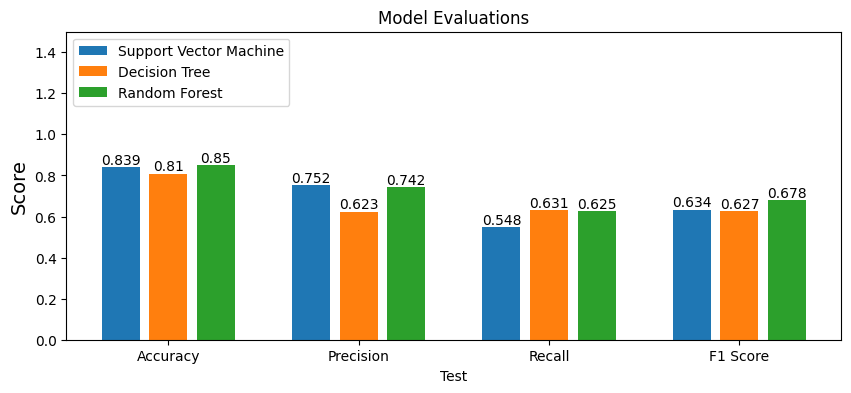

In [ ]:
# Graphs out the scores for each test with all of the models
bar_width = 0.4
plt.figure(figsize=(10,4))
plt.bar(x_axis - 0.25, svm_scores, width = bar_width/2, label = "Support Vector Machine")
plt.bar(x_axis, decision_tree_scores, width = bar_width/2, label = "Decision Tree")
plt.bar(x_axis + 0.25, random_forest_scores, width = bar_width/2, label = "Random Forest")
plt.xticks(x_axis, tests, rotation = 0)

add_labels(x_axis-0.25, np.around(svm_scores,3))
add_labels(x_axis, np.around(decision_tree_scores,3))
add_labels(x_axis+0.25, np.around(random_forest_scores,3))
plt.xlabel("Test")
plt.ylabel("Score", fontsize = 14)
plt.title("Model Evaluations")
plt.ylim(0,1.5)
plt.legend(loc = "upper left")
plt.show()